In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
     

In [2]:
data=pd.read_csv("dbscan_simple_dataset.csv")
data

,ID,Age,AnnualIncome
0,1,22,25
1,2,23,26
2,3,21,24
3,4,24,27
4,5,22,26
5,6,23,25
6,7,45,60
7,8,46,61
8,9,44,59
9,10,45,62


In [3]:

print("\nMissing Values")
print(data.isnull().sum())
     


Missing Values
ID              0
Age             0
AnnualIncome    0
dtype: int64


In [4]:

data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

In [6]:
X = data[
    [
        "Age",
        "AnnualIncome"
    ]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(
    eps=0.3,
    min_samples=4
)

In [8]:
clusters = dbscan.fit_predict(X_scaled)

In [9]:


     

clusters = dbscan.fit_predict(X_scaled)
     

data["Cluster"] = clusters

print("\nCluster Summary")
print(data["Cluster"].value_counts())

for i in sorted(data["Cluster"].unique()):

    print("\n" + "="*50)

    if i == -1:
        print("NOISE POINTS")
    else:
        print("CLUSTER", i + 1)

    print("="*50)

    cluster_data = data[
        data["Cluster"] == i
    ]

    print(
        cluster_data[
            [
                "Age",
                "AnnualIncome"
            ]
        ]
    )

    print(
        "\nTotal Records :",
        len(cluster_data)
    )


Cluster Summary
Cluster
 0    6
 1    6
-1    3
Name: count, dtype: int64

NOISE POINTS
    Age  AnnualIncome
12   30            90
13   60            20
14   18            75

Total Records : 3

CLUSTER 1
   Age  AnnualIncome
0   22            25
1   23            26
2   21            24
3   24            27
4   22            26
5   23            25

Total Records : 6

CLUSTER 2
    Age  AnnualIncome
6    45            60
7    46            61
8    44            59
9    45            62
10   46            60
11   44            61

Total Records : 6


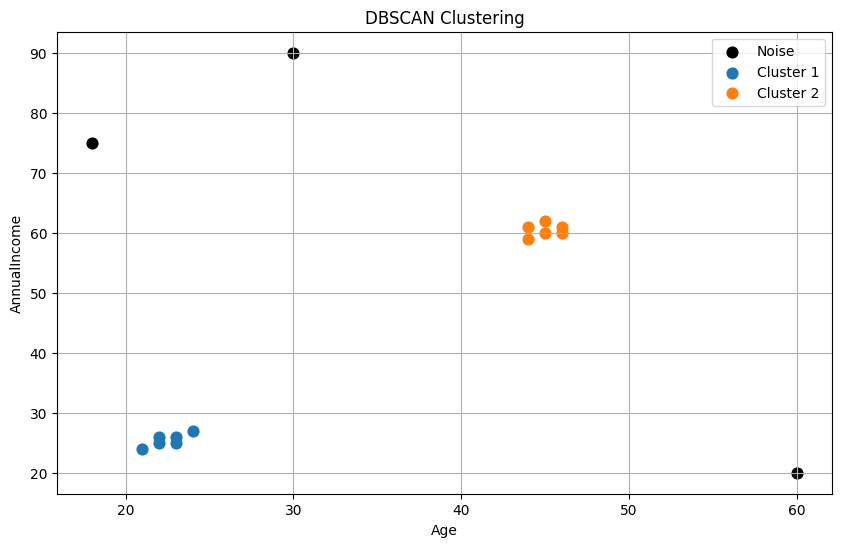

In [11]:
plt.figure(figsize=(10,6))

for cluster in sorted(data["Cluster"].unique()):

    cluster_data = data[
        data["Cluster"] == cluster
    ]

    if cluster == -1:

        plt.scatter(
            cluster_data["Age"],
            cluster_data["AnnualIncome"],
            color="black",
            label="Noise",
            s=60
        )

    else:

        plt.scatter(
            cluster_data["Age"],
            cluster_data["AnnualIncome"],
            label=f"Cluster {cluster+1}",
            s=60
        )
        plt.xlabel("Age")
plt.ylabel("AnnualIncome")

plt.title("DBSCAN Clustering")

plt.legend()
plt.grid(True)

plt.show()